In [1]:
# Import libraries
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Set project paths
PROJECT_ROOT = Path("..")
RAW_DATA_PATH = Path("../data/raw/crop_yield_data.xlsx")
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"
FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"

PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

### 1. Load Raw Data

In [5]:
df_raw = pd.read_excel(RAW_DATA_PATH)


original_shape = df_raw.shape
df = df_raw.copy()

print(f"Original dataset shape: {original_shape}")
df.head()

Original dataset shape: (1000, 8)


,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre),Crop Type
0,1230,80,28,80,24,20,12.0,Corn
1,480,60,36,70,20,18,8.0,Sorghum
2,1250,75,29,78,22,19,11.0,Soybean
3,450,65,35,70,19,18,9.0,Sorghum
4,1200,80,27,79,22,19,11.0,Wheat


The raw dataset was loaded from the `data/raw` folder. A copy was created so that the original dataset remained unchanged.

### 2. Inspect the dataset

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rain Fall (mm)  1000 non-null   int64  
 1   Fertilizer      1000 non-null   int64  
 2   Temperatue      1000 non-null   int64  
 3   Nitrogen (N)    1000 non-null   int64  
 4   Phosphorus (P)  1000 non-null   int64  
 5   Potassium (K)   1000 non-null   int64  
 6   Yeild (Q/acre)  1000 non-null   float64
 7   Crop Type       1000 non-null   str    
dtypes: float64(1), int64(6), str(1)
memory usage: 68.0 KB


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Rain Fall (mm),1000.0,NaN,NaN,NaN,897.9,302.908385,400.0,619.0,905.0,1175.25,1398.0
Fertilizer,1000.0,NaN,NaN,NaN,73.844,14.076427,50.0,61.0,74.0,85.0,99.0
Temperatue,1000.0,NaN,NaN,NaN,29.581,5.782463,20.0,25.0,29.0,34.0,40.0
Nitrogen (N),1000.0,NaN,NaN,NaN,74.489,8.507188,59.0,67.0,75.0,82.0,89.0
Phosphorus (P),1000.0,NaN,NaN,NaN,21.819,4.219009,15.0,18.0,22.0,26.0,29.0
Potassium (K),1000.0,NaN,NaN,NaN,16.93,4.102674,10.0,13.0,17.0,20.0,24.0
Yeild (Q/acre),1000.0,NaN,NaN,NaN,9.8666,2.803795,5.0,7.375,9.9,12.2,15.0
Crop Type,1000,6,Sorghum,174,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Rain Fall (mm),1000.0,NaN,NaN,NaN,897.9,302.908385,400.0,619.0,905.0,1175.25,1398.0
Fertilizer,1000.0,NaN,NaN,NaN,73.844,14.076427,50.0,61.0,74.0,85.0,99.0
Temperatue,1000.0,NaN,NaN,NaN,29.581,5.782463,20.0,25.0,29.0,34.0,40.0
Nitrogen (N),1000.0,NaN,NaN,NaN,74.489,8.507188,59.0,67.0,75.0,82.0,89.0
Phosphorus (P),1000.0,NaN,NaN,NaN,21.819,4.219009,15.0,18.0,22.0,26.0,29.0
Potassium (K),1000.0,NaN,NaN,NaN,16.93,4.102674,10.0,13.0,17.0,20.0,24.0
Yeild (Q/acre),1000.0,NaN,NaN,NaN,9.8666,2.803795,5.0,7.375,9.9,12.2,15.0
Crop Type,1000,6,Sorghum,174,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The dataset was inspected to understand its dimensions, variables, data types and summary statistics before cleaning.

### 3. Clean column names

In [9]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^a-z0-9_]", "", regex=True)
)

df.columns.tolist()

['rain_fall_mm',
 'fertilizer',
 'temperatue',
 'nitrogen_n',
 'phosphorus_p',
 'potassium_k',
 'yeild_qacre',
 'crop_type']

### 4. Check missing values

In [10]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100
})

missing_summary

,missing_count,missing_percentage
rain_fall_mm,0,0.0
fertilizer,0,0.0
temperatue,0,0.0
nitrogen_n,0,0.0
phosphorus_p,0,0.0
potassium_k,0,0.0
yeild_qacre,0,0.0
crop_type,0,0.0


Explain

### 5. Check duplicates

In [11]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 1


In [12]:
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)

Explain

### 6. Check data types

In [13]:
df.dtypes

rain_fall_mm      int64
fertilizer        int64
temperatue        int64
nitrogen_n        int64
phosphorus_p      int64
potassium_k       int64
yeild_qacre     float64
crop_type           str
dtype: object

In [14]:
numeric_columns = [
    "rainfall",
    "temperature",
    "fertilizer",
    "nitrogen",
    "phosphorus",
    "potassium",
    "yield"
]

numeric_columns = [col for col in numeric_columns if col in df.columns]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [15]:
df.dtypes

rain_fall_mm      int64
fertilizer        int64
temperatue        int64
nitrogen_n        int64
phosphorus_p      int64
potassium_k       int64
yeild_qacre     float64
crop_type           str
dtype: object

### 7. Standardise crop labels

In [16]:
if "crop" in df.columns:
    df["crop"] = (
        df["crop"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
    )

    print(df["crop"].value_counts())

### 8. Check invalid values

In [17]:
validation_summary = {}

for col in numeric_columns:
    validation_summary[col] = {
        "minimum": df[col].min(),
        "maximum": df[col].max(),
        "negative_values": int((df[col] < 0).sum())
    }

pd.DataFrame(validation_summary).T

,minimum,maximum,negative_values
fertilizer,50,99,0


In [18]:
for col in ["rainfall", "fertilizer", "nitrogen", "phosphorus", "potassium", "yield"]:
    if col in df.columns:
        print(f"{col}: {(df[col] < 0).sum()} negative values")

fertilizer: 0 negative values


Expalanation - Negative rainfall, fertiliser, nutrient or yield values would usually require investigation.

Temperature should not automatically be restricted to positive values without knowing the dataset context.

### 9. Outlier assessment

In [19]:
def iqr_outlier_summary(data, columns):
    results = []

    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_count = (
            (data[col] < lower_bound) |
            (data[col] > upper_bound)
        ).sum()

        results.append({
            "variable": col,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": int(outlier_count)
        })

    return pd.DataFrame(results)

In [20]:
outlier_summary = iqr_outlier_summary(df, numeric_columns)
outlier_summary

,variable,lower_bound,upper_bound,outlier_count
0,fertilizer,25.0,121.0,0


### 10.Final data-quality check

In [21]:
print(f"Original shape: {original_shape}")
print(f"Final shape: {df.shape}")
print(f"Remaining missing values: {df.isna().sum().sum()}")
print(f"Remaining duplicate rows: {df.duplicated().sum()}")

Original shape: (1000, 8)
Final shape: (999, 8)
Remaining missing values: 0
Remaining duplicate rows: 0


### 11. Save only the cleaned

In [23]:
cleaned_file = PROCESSED_DATA_PATH / "crop_yield_cleaned.csv"

df.to_csv(cleaned_file, index=False)

print(f"Cleaned dataset saved to: {cleaned_file}")

Cleaned dataset saved to: ../data/processed/crop_yield_cleaned.csv


### 12. Cleaning summary table

In [22]:
cleaning_summary = pd.DataFrame({
    "item": [
        "Original rows",
        "Original columns",
        "Final rows",
        "Final columns",
        "Duplicate rows removed",
        "Remaining missing values"
    ],
    "value": [
        original_shape[0],
        original_shape[1],
        df.shape[0],
        df.shape[1],
        duplicate_count,
        int(df.isna().sum().sum())
    ]
})

cleaning_summary

,item,value
0,Original rows,1000
1,Original columns,8
2,Final rows,999
3,Final columns,8
4,Duplicate rows removed,1
5,Remaining missing values,0


# Exploratory Data Analysis

In [3]:
# Import important packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 
import math

In [4]:
data=pd.read_csv(r"C:\Users\uzing\Downloads\crop_yield_cleaned.csv")

In [5]:
# Gather descriptive statistics about the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
rain_fall_mm,999.0,897.567568,302.877541,400.0,619.00,905.0,1175.0,1398.0
fertilizer,999.0,73.837838,14.082128,50.0,61.00,74.0,85.0,99.0
temperatue,999.0,29.582583,5.785142,20.0,25.00,29.0,34.0,40.0
nitrogen_n,999.0,74.483483,8.509660,59.0,67.00,75.0,82.0,89.0
phosphorus_p,999.0,21.816817,4.220557,15.0,18.00,22.0,26.0,29.0
potassium_k,999.0,16.926927,4.103577,10.0,13.00,17.0,20.0,24.0
yeild_qacre,999.0,9.864464,2.804385,5.0,7.35,9.9,12.2,15.0


In [6]:
data.head(10)

,rain_fall_mm,fertilizer,temperatue,nitrogen_n,phosphorus_p,potassium_k,yeild_qacre,crop_type
0,1230,80,28,80,24,20,12.0,Corn
1,480,60,36,70,20,18,8.0,Sorghum
2,1250,75,29,78,22,19,11.0,Soybean
3,450,65,35,70,19,18,9.0,Sorghum
4,1200,80,27,79,22,19,11.0,Wheat
5,500,70,34,74,22,16,10.0,Barley
6,1275,71,28,77,21,20,11.0,Corn
7,425,65,37,67,18,15,7.0,Corn
8,1200,77,27,78,23,20,12.0,Sorghum
9,400,50,39,60,18,15,6.0,Barley


# Crop Type Distribution

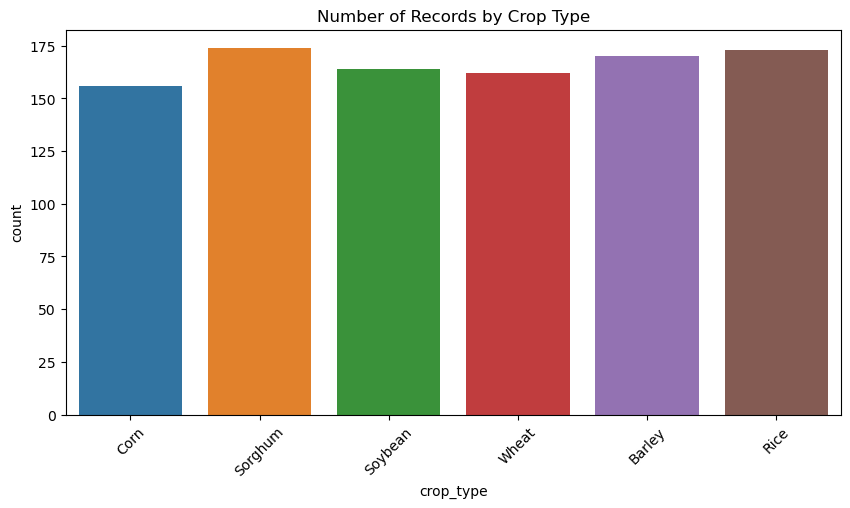

In [24]:
plt.figure(figsize=(10,5))
sns.countplot(data=data, x='crop_type')
plt.xticks(rotation=45)
plt.title("Number of Records by Crop Type")
plt.savefig("C:\\Users\\uzing\\Desktop\\iiAfrica\\crop_type_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

# Average Yield by Crop

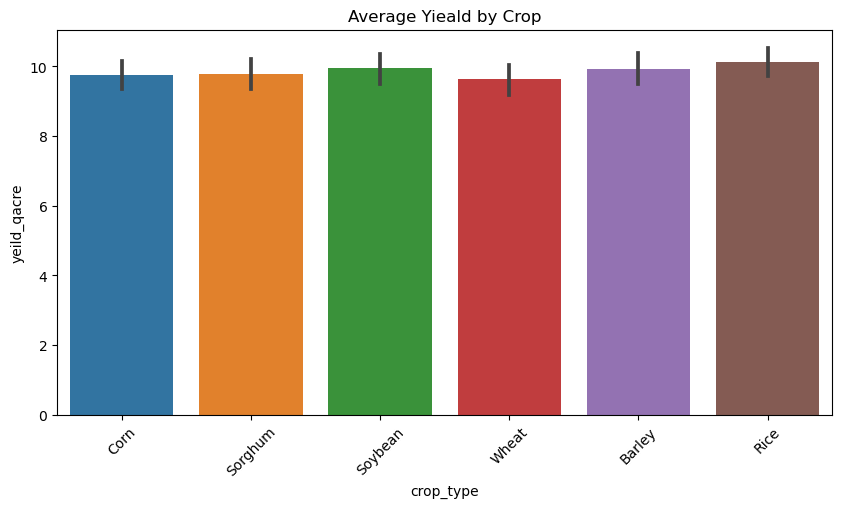

In [25]:
plt.figure(figsize=(10,5))
sns.barplot(data=data,
           x='crop_type',
           y='yeild_qacre',
           estimator=np.mean)
plt.xticks(rotation=45)
plt.title("Average Yieald by Crop")
plt.savefig("C:\\Users\\uzing\\Desktop\\iiAfrica\\yield_by_crop.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

## Rainfall vs Yield by crop type

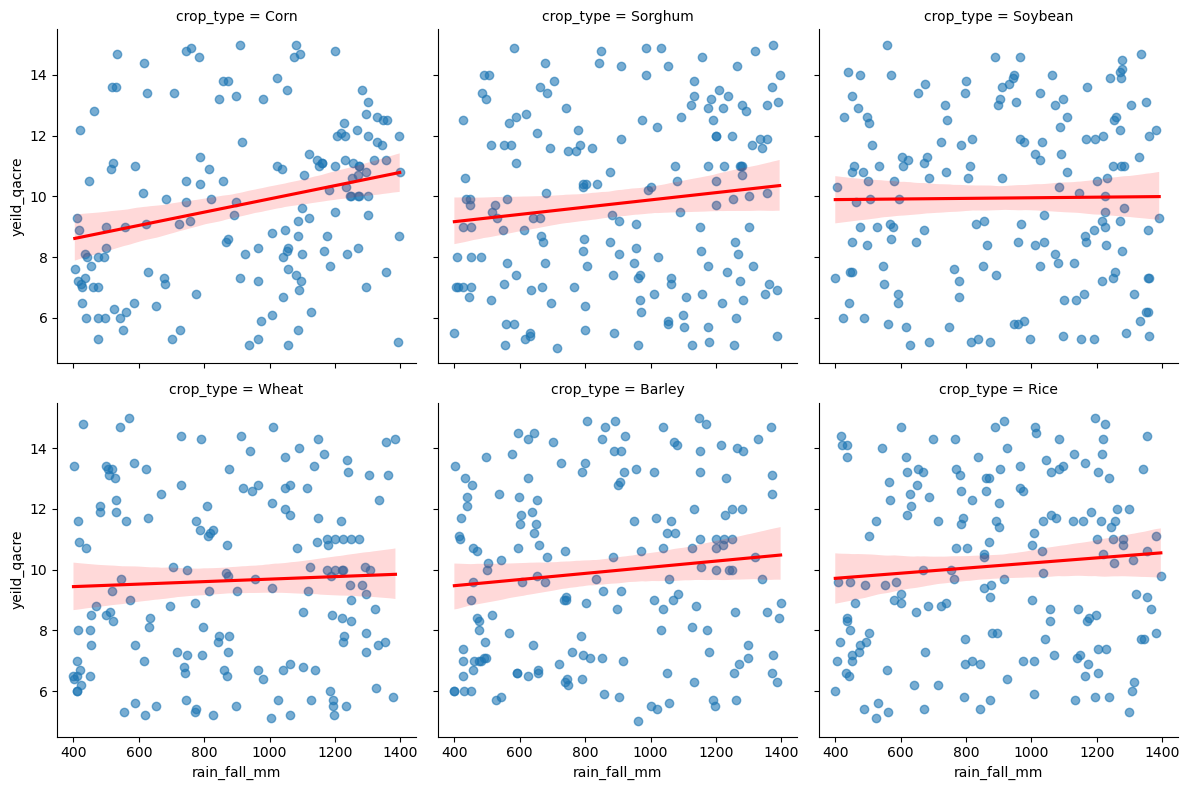

In [27]:
plot = sns.lmplot(
    data=data,
    x="rain_fall_mm",
    y="yeild_qacre",
    col="crop_type",
    col_wrap=3,
    height=4,
    scatter_kws={"alpha":0.6},
    line_kws={"color":"red"}
)
plot.savefig("C:\\Users\\uzing\\Desktop\\iiAfrica\\rainfall_vs_yield.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

## Temperature vs Yield by Crop Type

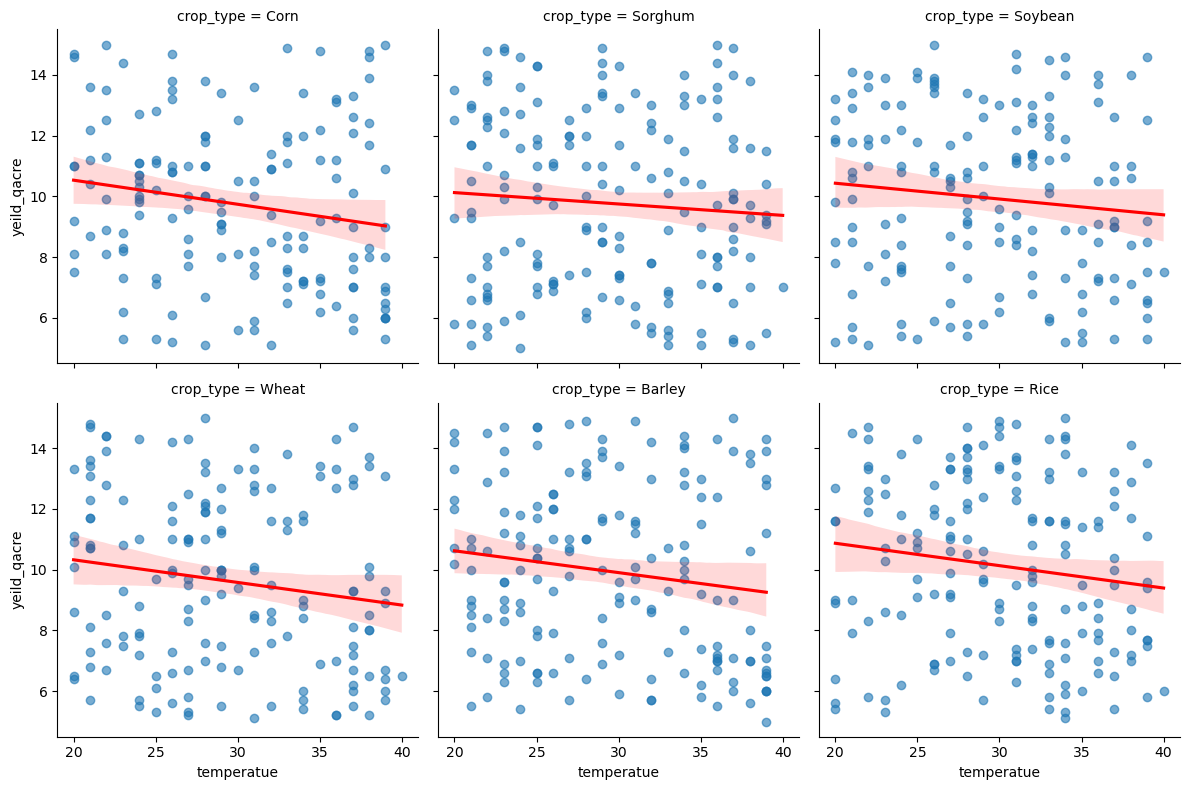

In [28]:
plot= sns.lmplot(
    data=data,
    x="temperatue",
    y="yeild_qacre",
    col="crop_type",
    col_wrap=3,
    height=4,
    scatter_kws={"alpha":0.6},
    line_kws={"color":"red"}
)
plot.savefig("C:\\Users\\uzing\\Desktop\\iiAfrica\\temperatue_vs_yield.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

## Fertilizer vs Yield by Crop Type

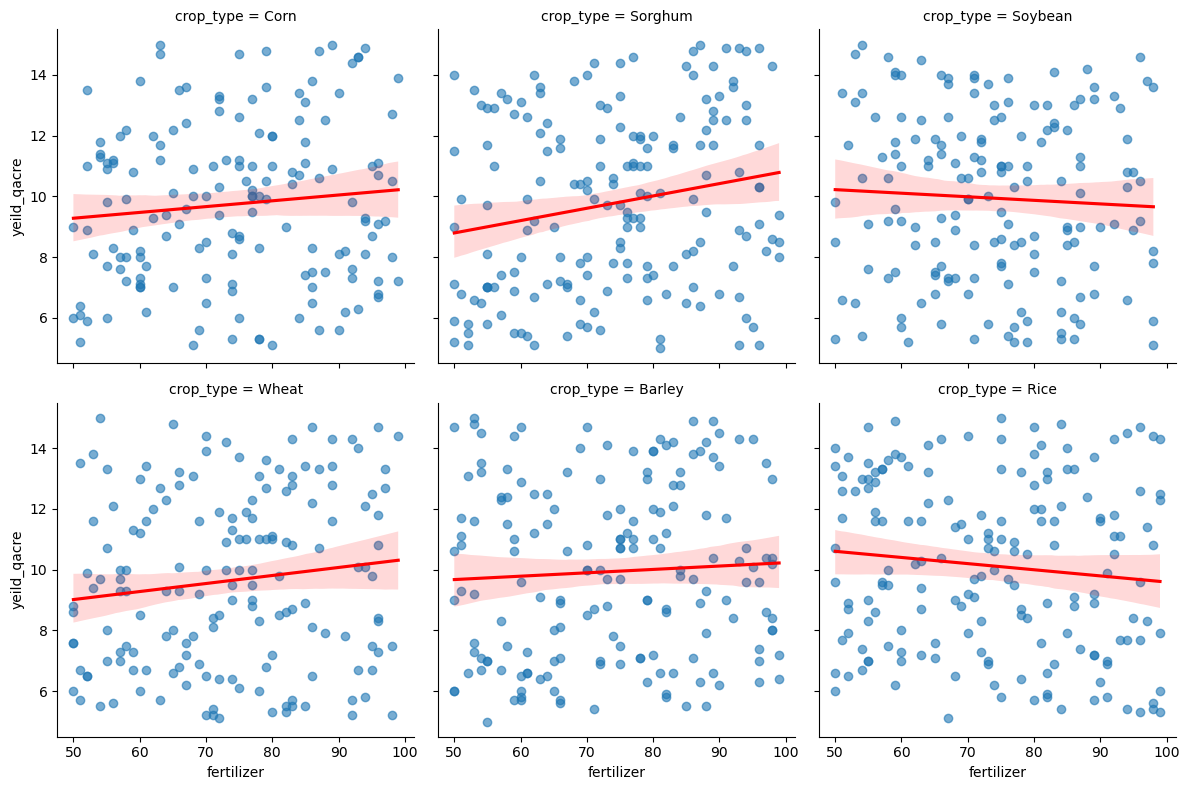

In [29]:
plot = sns.lmplot(
    data=data,
    x="fertilizer",
    y="yeild_qacre",
    col="crop_type",
    col_wrap=3,
    height=4,
    scatter_kws={"alpha":0.6},
    line_kws={"color":"red"}
)
plot.savefig("C:\\Users\\uzing\\Desktop\\iiAfrica\\fertilizer_vs_yield.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

## Nitrogen vs yield by Crop Type

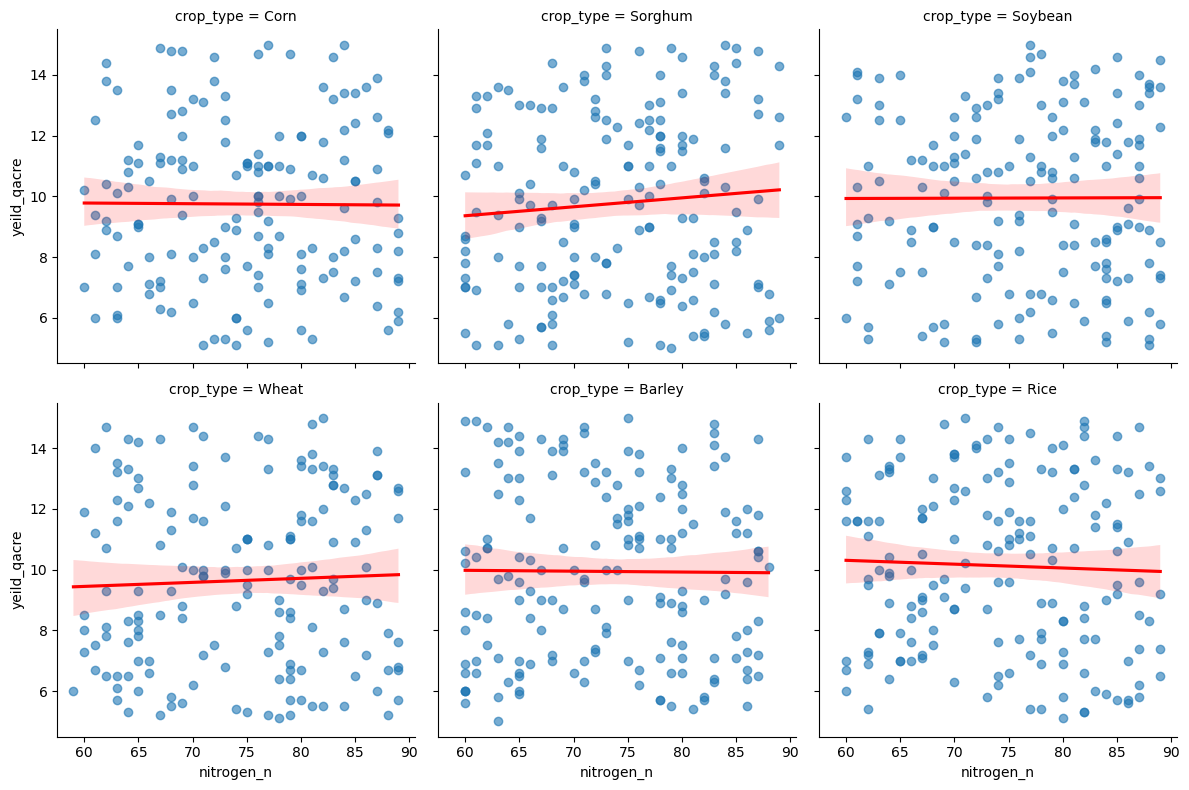

In [30]:
plot = sns.lmplot(
    data=data,
    x="nitrogen_n",
    y="yeild_qacre",
    col="crop_type",
    col_wrap=3,
    height=4,
    scatter_kws={"alpha":0.6},
    line_kws={"color":"red"}
)
plot.savefig("C:\\Users\\uzing\\Desktop\\iiAfrica\\nitrogen_vs_yield.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

## Phosphorus vs Yield by Crop Type

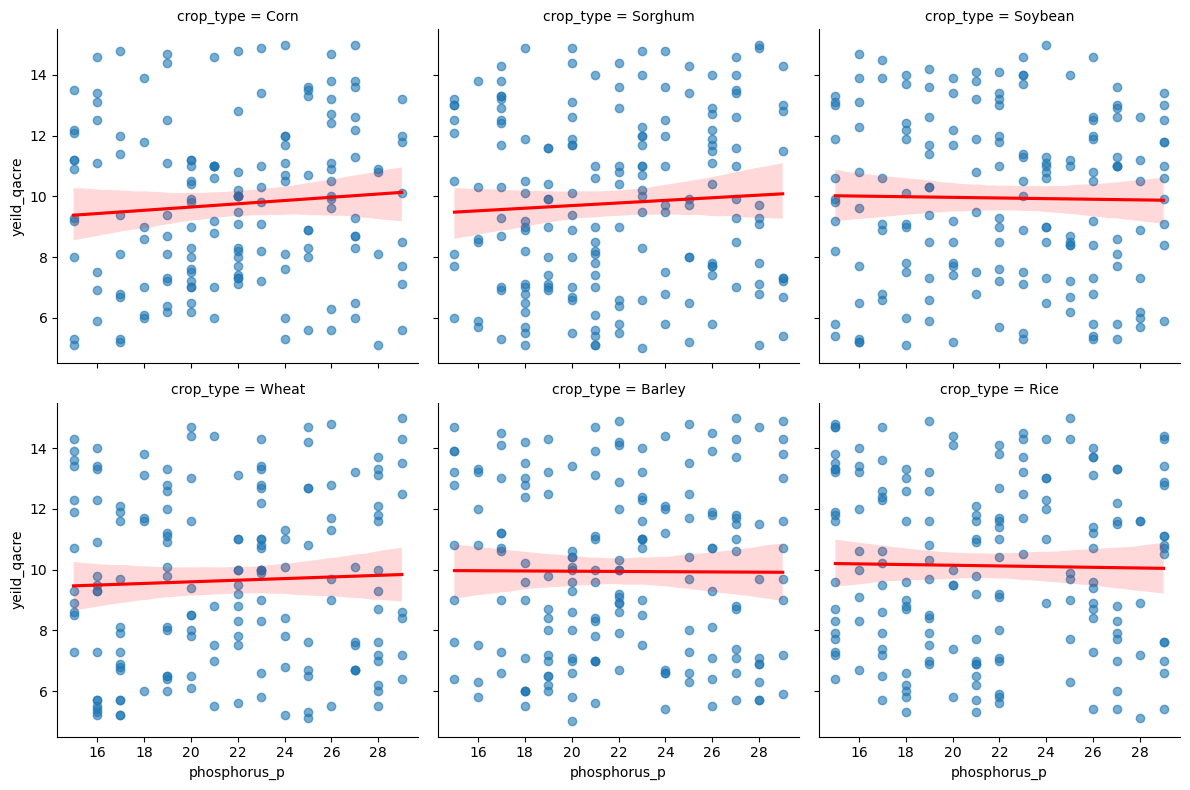

In [32]:
plot = sns.lmplot(
    data=data,
    x="phosphorus_p",
    y="yeild_qacre",
    col="crop_type",
    col_wrap=3,
    height=4,
    scatter_kws={"alpha":0.6},
    line_kws={"color":"red"}
)
plot.savefig("C:\\Users\\uzing\\Desktop\\iiAfrica\\phosphorus_vs_yield.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

## Potassium vs Yield by Crop Type

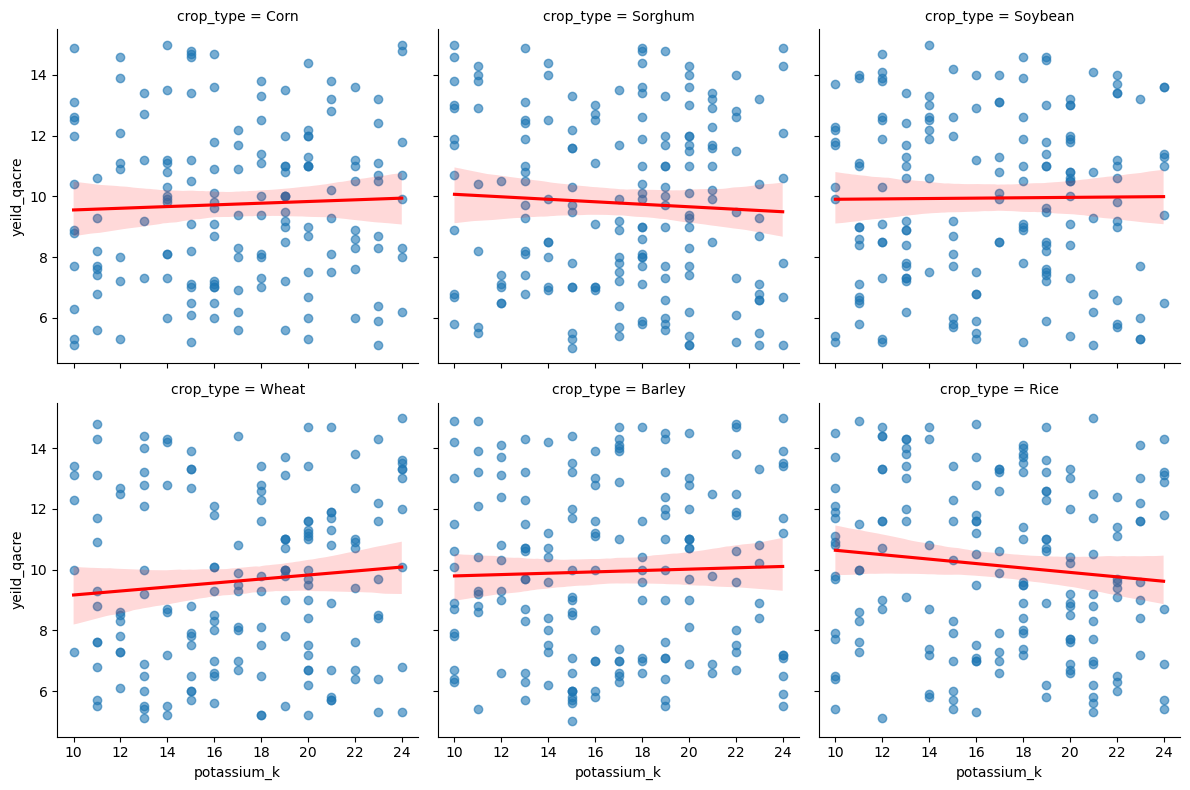

In [33]:
plot = sns.lmplot(
    data=data,
    x="potassium_k",
    y="yeild_qacre",
    col="crop_type",
    col_wrap=3,
    height=4,
    scatter_kws={"alpha":0.6},
    line_kws={"color":"red"}
)
plot.savefig("C:\\Users\\uzing\\Desktop\\iiAfrica\\potassium_vs_yield.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

## Correlation Matrix

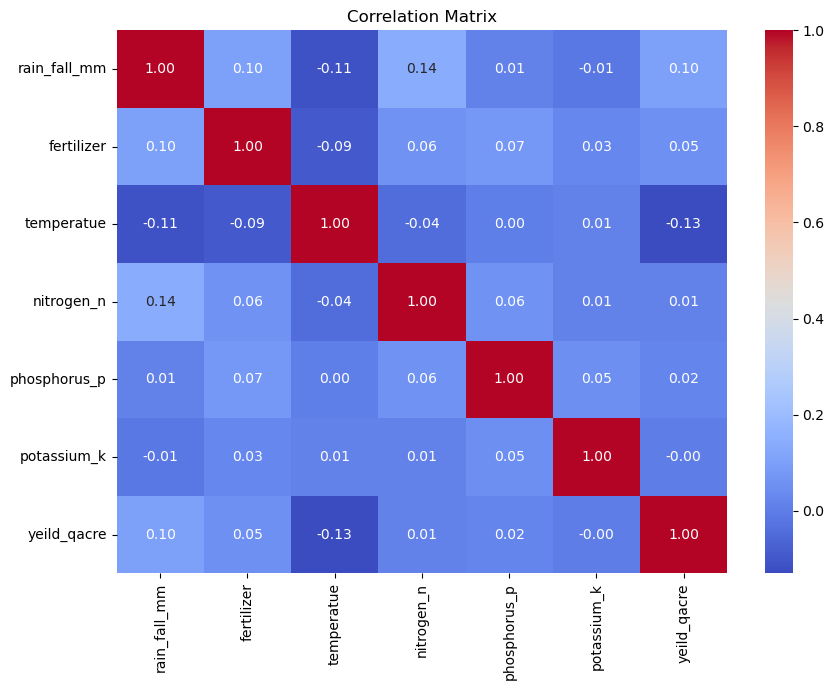

In [34]:
numeric_df = data.select_dtypes(include=np.number)

plt.figure(figsize=(9,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.savefig("C:\\Users\\uzing\\Desktop\\iiAfrica\\correlation_matrix.png",
            dpi=300,
            bbox_inches="tight")
plt.show()